In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [7]:
x,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [10]:
df=pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.000033,-0.591037,-1.727413,1.368353,0.824921,0
1,-1.430541,-2.093263,2.566740,3.518984,-0.911111,1
2,-0.766342,-0.899946,0.362742,0.809344,0.287019,0
3,-2.104994,0.871873,0.916509,1.990279,2.645484,1
4,-1.559789,3.942590,-1.776551,-1.812562,3.880751,1


In [11]:
#fetch random dat from rows
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [56]:
#for featur sampling
import random
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [79]:
#function for combining sampling
def combined_sampling(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [16]:
df1=sample_rows(df,0.1)

In [18]:
df2=sample_rows(df,0.1)

In [17]:
df3=sample_rows(df,0.1)

In [20]:
df3.shape

(10, 6)

In [25]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()


In [35]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df1.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df1.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.4, 0.8333333333333334, 'x[4] <= 0.352\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 1.987\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

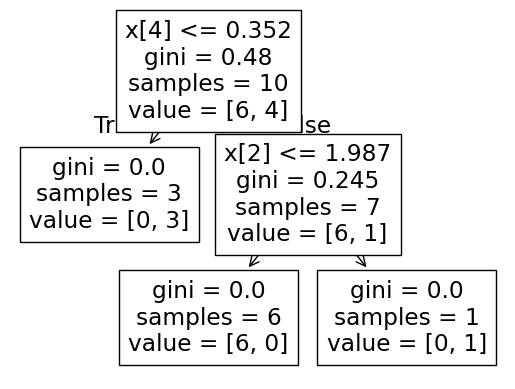

In [36]:
plot_tree(clf1)

In [28]:
from sklearn.tree import plot_tree

[Text(0.5, 0.9, 'x[4] <= 1.652\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.3333333333333333, 0.7, 'x[0] <= -1.814\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.5, 'x[3] <= 2.39\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.6666666666666666, 0.3, 'x[0] <= -1.494\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.7, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5833333333333333, 0.8, '  False')]

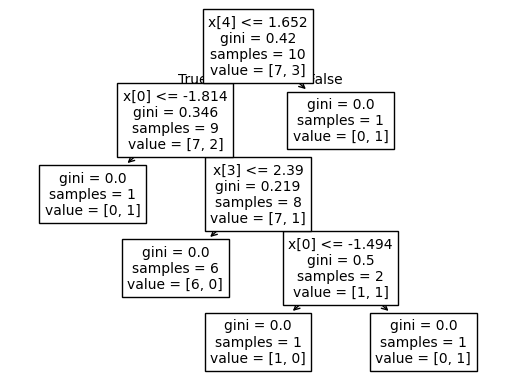

In [37]:
plot_tree(clf2)


[Text(0.4, 0.875, 'x[2] <= 0.424\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[4] <= 0.387\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[2] <= 1.526\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

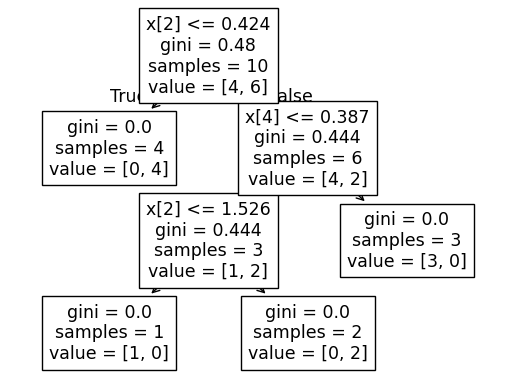

In [38]:
plot_tree(clf3)

In [39]:


clf1.predict(np.array([-1.000033	,-0.591037,	-1.727413,	1.368353,	0.824921]).reshape(1,5))

C:\Users\rg943\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [40]:
clf2.predict(np.array([-1.000033	,-0.591037,	-1.727413,	1.368353,	0.824921]).reshape(1,5))

C:\Users\rg943\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [41]:
clf3.predict(np.array([-1.000033	,-0.591037,	-1.727413,	1.368353,	0.824921]).reshape(1,5))

C:\Users\rg943\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [42]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
79,-2.258613,0.510534,-0.093915,0.716093,0.271398,0
42,2.270463,1.917332,0.584694,2.232578,0.540952,1
43,0.574657,1.640144,0.614608,1.111112,0.300621,1
72,-0.777379,1.996443,-0.539713,0.622148,2.338456,1
69,-1.882467,0.812356,0.916705,0.790884,0.567666,1
30,-0.726275,-0.505809,-1.689532,1.856085,1.556707,0
64,-2.076181,-0.459180,-0.049878,0.816090,0.538531,0
19,-1.475349,-0.261660,1.259078,1.502234,0.609209,0
17,-1.965906,-2.245046,-1.022126,0.572014,1.163938,0
11,-1.044421,-0.117035,1.940088,2.041896,0.143881,1


In [57]:
df1=sample_features(df,0.8)

C:\Users\rg943\AppData\Local\Temp\ipykernel_25032\1495751315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [58]:
df2=sample_features(df,0.8)

C:\Users\rg943\AppData\Local\Temp\ipykernel_25032\1495751315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [59]:
df3=sample_features(df,0.8)

C:\Users\rg943\AppData\Local\Temp\ipykernel_25032\1495751315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [60]:
df3.shape

(100, 5)

In [61]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df1.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df1.iloc[:,0:4],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.9, 'x[2] <= 0.395\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2222222222222222, 0.7, 'x[1] <= 2.001\ngini = 0.391\nsamples = 60\nvalue = [44, 16]'),
 Text(0.3611111111111111, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'x[3] <= -0.608\ngini = 0.127\nsamples = 44\nvalue = [41, 3]'),
 Text(0.05555555555555555, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.3, 'x[0] <= -3.561\ngini = 0.046\nsamples = 42\nvalue = [41, 1]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 41\nvalue = [41, 0]'),
 Text(0.3333333333333333, 0.5, 'x[3] <= 1.453\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.2777777777777778, 0.3, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.3888888888888889, 0.3, 'x[0] <= -1.558\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 

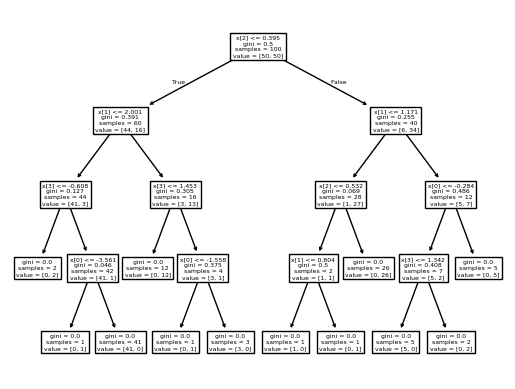

In [63]:
plot_tree(clf1)

[Text(0.5, 0.9, 'x[2] <= 0.395\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2222222222222222, 0.7, 'x[1] <= 2.001\ngini = 0.391\nsamples = 60\nvalue = [44, 16]'),
 Text(0.3611111111111111, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'x[3] <= -0.608\ngini = 0.127\nsamples = 44\nvalue = [41, 3]'),
 Text(0.05555555555555555, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.3, 'x[0] <= -3.561\ngini = 0.046\nsamples = 42\nvalue = [41, 1]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 41\nvalue = [41, 0]'),
 Text(0.3333333333333333, 0.5, 'x[3] <= 1.453\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.2777777777777778, 0.3, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.3888888888888889, 0.3, 'x[0] <= -1.558\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 

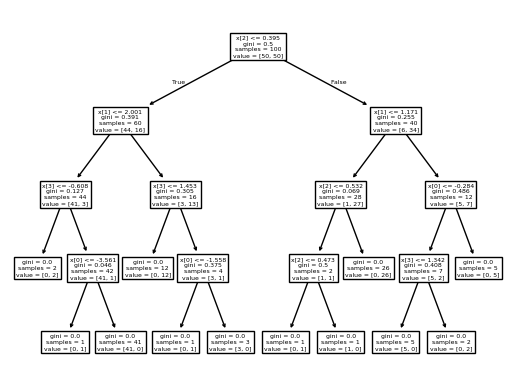

In [62]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[2] <= 0.395\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2222222222222222, 0.7, 'x[1] <= 2.001\ngini = 0.391\nsamples = 60\nvalue = [44, 16]'),
 Text(0.3611111111111111, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'x[3] <= -0.608\ngini = 0.127\nsamples = 44\nvalue = [41, 3]'),
 Text(0.05555555555555555, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.3, 'x[3] <= 2.757\ngini = 0.046\nsamples = 42\nvalue = [41, 1]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 41\nvalue = [41, 0]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'x[3] <= 1.453\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.2777777777777778, 0.3, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.3888888888888889, 0.3, 'x[3] <= 2.546\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4444444444444444, 0.

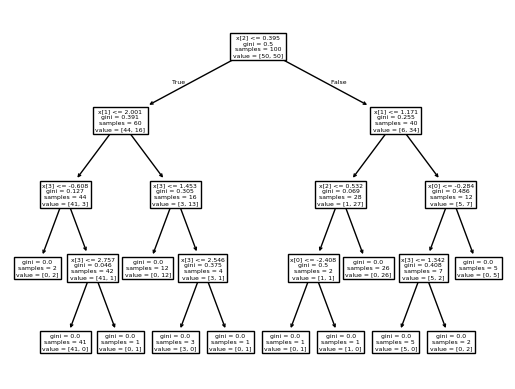

In [64]:
plot_tree(clf3)

### 

In [65]:
df3

,col1,col4,col3,col5,target
0,-1.000033,1.368353,-1.727413,0.824921,0
1,-1.430541,3.518984,2.566740,-0.911111,1
2,-0.766342,0.809344,0.362742,0.287019,0
3,-2.104994,1.990279,0.916509,2.645484,1
4,-1.559789,-1.812562,-1.776551,3.880751,1
...,...,...,...,...,...
95,-0.633477,3.098442,1.755525,1.504267,1
96,-1.537544,2.153022,0.849403,1.401928,1
97,-1.147699,-0.239658,-0.770471,1.134472,1
98,-1.835998,0.666188,0.996091,-0.097612,0


In [70]:
clf1.predict(np.array([-1.000033,	1.368353,	-1.727413,	0.824921	]).reshape(1,4))


C:\Users\rg943\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [71]:
clf2.predict(np.array([-1.000033,	1.368353,	-1.727413,	0.82492	]).reshape(1,4))


C:\Users\rg943\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [72]:
clf3.predict(np.array([-1.000033,	1.368353,	-1.727413,	0.82492	]).reshape(1,4))

C:\Users\rg943\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [81]:
df1=combined_sampling(df,0.5,0.5)

C:\Users\rg943\AppData\Local\Temp\ipykernel_25032\1495751315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [82]:
df2=combined_sampling(df,0.5,0.5)

C:\Users\rg943\AppData\Local\Temp\ipykernel_25032\1495751315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [83]:
df3=combined_sampling(df,0.5,0.5)

C:\Users\rg943\AppData\Local\Temp\ipykernel_25032\1495751315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [84]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'col4', 'target'], dtype='object')
Index(['col2', 'col3', 'col4', 'target'], dtype='object')
Index(['col2', 'col3', 'col4', 'target'], dtype='object')


In [85]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df1.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df1.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.4666666666666667, 0.9285714285714286, 'x[0] <= 1.663\ngini = 0.487\nsamples = 50\nvalue = [29.0, 21.0]'),
 Text(0.4, 0.7857142857142857, 'x[1] <= -1.365\ngini = 0.439\nsamples = 43\nvalue = [29.0, 14.0]'),
 Text(0.43333333333333335, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'x[0] <= 0.553\ngini = 0.18\nsamples = 20\nvalue = [18, 2]'),
 Text(0.06666666666666667, 0.5, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.2, 0.5, 'x[0] <= 1.156\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.13333333333333333, 0.35714285714285715, 'x[1] <= -2.319\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.06666666666666667, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.26666666666666666, 0.35714285714285715, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6666666666666666, 0.6428571428571429, 'x[0] <= 0.808\ngini = 0.499\nsamples = 23\nvalu

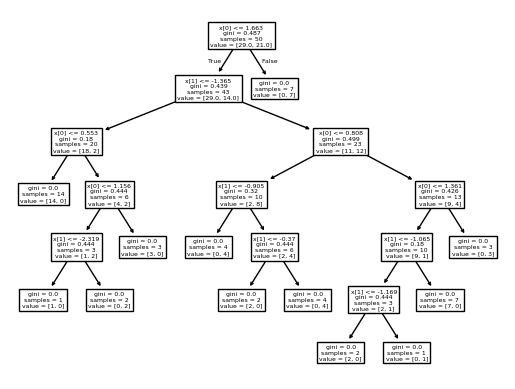

In [86]:
plot_tree(clf1)